# Project: Sudoku Variant AI — Diagnostic & Strategy Notebook
**Objective:** *Analyze failure modes of BlackBoxBreakerCNN and implement Hindsight Backtracking.*

### 🛠️ Section 1: Environment & Architecture Setup
1. Load the 50,000-puzzle test dataset JSON.
2. Instantiate BlackBoxBreakerCNN and load the best_sudoku_model.pth weights.
3. Verify tensor dimensions across the pipeline.

### 🔍 Section 2: Error Classification & Distribution (The "Why")
- Row/Column/Block Violation Matrix: Code to parse the failed boards and count exactly which constraints are violated most frequently.
- Confidence vs. Correctness Plot: A scatter plot matching the model's confidence for a selection against whether the digit actually matches the ground truth solution.
- The "Blunder Step" Distribution: A histogram showing exactly at which step (Step 1, Step 2, etc.) the first logical mistake typically occurs across 100 failed puzzles.

### 🔄 Section 3: The Hindsight Wrapper (Backtracking Integration)
1. Define the state tracking mechanism (Move History).
2. Implement the confidence threshold parameter ($\tau$) to trigger a roll-back when a downstream confidence drop is detected.
3. Comparative benchmark: Run the new wrapper over the same test batch to chart the accuracy recovery curve.

#### 🗂️ Designing the Move History Tracker
To build the Hindsight Wrapper in Section 3, we need to track our journey through the decision tree so we can step backward when confidence plunges.  
A natural way to store this history is using a standard Python list as a Stack data structure, utilizing append() to push moves and pop() to undo them.

### Appendix: Utilities & Debugging Aids
- ML pipeline integrity checks and ground truth verification code snippets.

In [12]:
# Load the test dataset JSON
DATASET_ID = "1000000_10-40_1_1781310686"  # Update this with the actual dataset ID used in data_preparer.py
TARGET_TEST_DATASET = f"data/encoded/split/sudoku_puzzle_dataset_one_hot_encoded_{DATASET_ID}_test.json"
LOG_PATH = f"analysis/logs/results_sudoku_puzzle_dataset_one_hot_encoded_{DATASET_ID}_test.log"
JSON_FAILURES_PATH = f"analysis/logs/failed_puzzles_analysis_sudoku_puzzle_dataset_one_hot_encoded_{DATASET_ID}_test.json"

In [ ]:
# Section 1: Environment & Configuration
import json
import torch
import torch.nn.functional as F
from trainer import BlackBoxBreakerCNN, SudokuDataset

# 1. Load the split test dataset JSON
TEST_DATA_PATH = TARGET_TEST_DATASET
try:
    with open(TEST_DATA_PATH, "r") as f:
        test_json = json.load(f)
    print(f"📦 Successfully loaded test dataset with {len(test_json)} puzzles.")
except FileNotFoundError:
    print(f"❌ Error: Failed to load test dataset from {TEST_DATA_PATH}. Please ensure the file exists and the path is correct.")
    test_json = []

# 2. Instantiate the network and load trained weights
model = BlackBoxBreakerCNN()
model.load_state_dict(torch.load("models/best_sudoku_model.pth"))
model.eval()
print("🤖 Model architecture loaded and weights initialized.")

# 3. Verify tensor dimensions across the pipeline
# Grab a single raw sample from our loaded JSON
sample_entry = test_json[0]
raw_puzzle = torch.tensor(sample_entry['puzzle'], dtype=torch.float32)
print(f"\n📐 1. Shape from JSON dataset: {raw_puzzle.shape}")

# Permute to match PyTorch's expected CNN format (Channels, Height, Width)
permuted_puzzle = raw_puzzle.permute(2, 1, 0)
print(f"📐 2. Shape after permuting for PyTorch: {permuted_puzzle.shape}")

# Add the batch dimension for a single inference batch size of 1
input_tensor = permuted_puzzle.unsqueeze(0)
print(f"📐 3. Final 4D input shape ready for model: {input_tensor.shape}")

# Run a forward pass to check output shape consistency
with torch.no_grad():
    output_tensor = model(input_tensor)
print(f"📐 4. Model output prediction shape: {output_tensor.shape}")

📦 Successfully loaded test dataset with 50000 puzzles.
🤖 Model architecture loaded and weights initialized.

📐 1. Shape from JSON dataset: torch.Size([9, 9, 10])
📐 2. Shape after permuting for PyTorch: torch.Size([10, 9, 9])
📐 3. Final 4D input shape ready for model: torch.Size([1, 10, 9, 9])
📐 4. Model output prediction shape: torch.Size([1, 10, 9, 9])


❌ Error: Failed to load failure analysis data from analysis/logs/failed_puzzles_analysis_sudoku_puzzle_dataset_one_hot_encoded_1000000_10-40_1_1781310686_test.json. Please ensure the file exists and the path is correct.


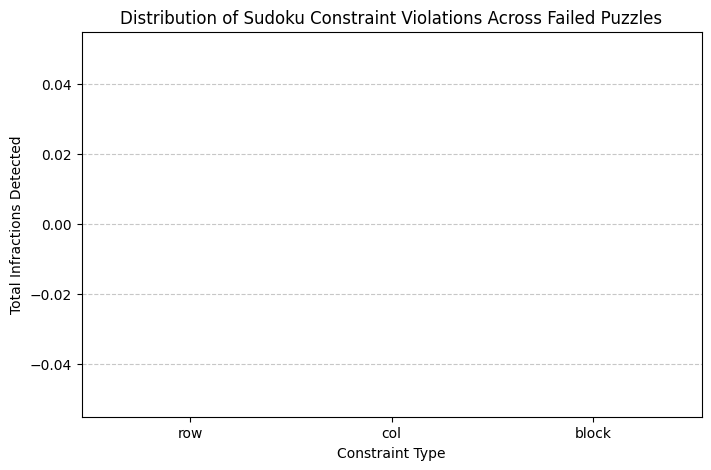

In [14]:
# Section 2: Error Classification & Distribution
import json
import matplotlib.pyplot as plt

# Load the compiled failure data
try:
    with open(JSON_FAILURES_PATH, "r") as f:
        failed_data = json.load(f)
    print(f"📊 Successfully loaded failure analysis data with {len(failed_data)} entries.")
except FileNotFoundError:
    print(f"❌ Error: Failed to load failure analysis data from {JSON_FAILURES_PATH}. Please ensure the file exists and the path is correct.")
    failed_data = []

# Aggregate total violation counts
total_violations = {"row": 0, "col": 0, "block": 0}
for entry in failed_data:
    total_violations["row"] += entry["violations"]["row"]
    total_violations["col"] += entry["violations"]["col"]
    total_violations["block"] += entry["violations"]["block"]

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.bar(total_violations.keys(), total_violations.values(), color=['#FF6B6B', '#4D96FF', '#6BCB77'])
plt.title("Distribution of Sudoku Constraint Violations Across Failed Puzzles")
plt.ylabel("Total Infractions Detected")
plt.xlabel("Constraint Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
# Appendix: ML Sanity Checks
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from trainer import BlackBoxBreakerCNN

# Grab the first puzzle entry
sample_entry = test_json[0]

# Extract and decode the one-hot matrix back into integers
one_hot_puzzle = np.array(sample_entry['puzzle'])  # Shape: (9, 9, 10)
original_integer_board = np.argmax(one_hot_puzzle, axis=-1)

# Print it to verify it looks like a real 9x9 Sudoku board
print("Original Integer Board Matrix:")
print(original_integer_board)

# -----------------------------
# DATA PIPELINE INTEGRITY CHECK
#------------------------------

# --------- BARRIER 1 ---------
# 1. Collect samples to verify the data pipeline integrity
raw_from_json = np.array(test_json[0]['puzzle']) # Expected shape from data_preparer: (9, 9, 10)
decoded_board = np.argmax(raw_from_json, axis=-1)

# 2. Check if it matches the ground truth initial integer board
print("Pipeline Integrity Seal:", "PASSED" if np.array_equal(decoded_board, original_integer_board) else "FAILED")

# --------- BARRIER 2 ---------
# 1. Isolate a single training sample from your JSON data
sample_entry = test_json[0]
puzzle_tensor = torch.tensor(sample_entry['puzzle'], dtype=torch.float32)  # (9, 9, 10)
target_tensor = torch.tensor(sample_entry['solution'], dtype=torch.long)    # (9, 9)

# 2. Apply our core structural fix: Permute to (Channels, Rows, Columns)
inputs = puzzle_tensor.permute(2, 0, 1).unsqueeze(0)  # Shape: (1, 10, 9, 9)
targets = target_tensor.unsqueeze(0)                  # Shape: (1, 9, 9)

# 3. Instantiate model, loss, and optimizer
model = BlackBoxBreakerCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Overfit Loop (Run for 50-100 quick iterations on CPU)
print("🏋️‍♂️ Starting Capacity Test (Overfitting 1 Puzzle)...")
model.train()
for epoch in range(1, 51):
    optimizer.zero_grad()
    outputs = model(inputs)  # Output shape: (1, 10, 9, 9)
    
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == 1:
        # Calculate how many cell digits match exactly
        predictions = torch.argmax(outputs, dim=1)
        correct_cells = (predictions == targets).sum().item()
        accuracy = (correct_cells / 81) * 100
        print(f"Epoch {epoch:02d}/50 | Loss: {loss.item():.4f} | Cell Accuracy: {accuracy:.2f}%")

Original Integer Board Matrix:
[[7 5 2 0 0 0 9 0 1]
 [4 0 6 9 8 1 7 5 2]
 [9 8 1 0 5 2 0 3 0]
 [5 2 4 0 6 9 8 0 7]
 [3 6 9 0 1 7 5 2 4]
 [8 0 7 0 2 4 3 6 9]
 [0 4 3 6 9 8 1 7 5]
 [6 9 8 1 0 5 2 4 3]
 [1 0 5 2 0 0 6 0 8]]
Pipeline Integrity Seal: PASSED
🏋️‍♂️ Starting Capacity Test (Overfitting 1 Puzzle)...


RuntimeError: only batches of spatial targets supported (3D tensors) but got targets of dimension: 4